# D — GOP behavior analysis

Reads artifacts from Group D. **Does not recompute GOP** (that is A1).

| File | Experiment |
| --- | --- |
| `outputs/D/d_predictions.csv` | A1 GOP + speaker / age / sentence accuracy / stratum |
| `outputs/D/d1_phone_metrics.csv` | D1 phone-level metrics |
| `outputs/D/d2_speaker_metrics.csv` | D2 speaker-level metrics |
| `outputs/D/d3_stratum_metrics.csv` | D3 score-stratum metrics |
| `outputs/D/d_results.json` | protocol + D1/D2/D3 |

```text
python scripts/run_experiment.py --config configs/d_gop_behavior.yaml
```

D3 strata are speaker-mean sentence-accuracy tertiles, **not** proficiency labels.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "outputs" / "D" / "d_results.json").is_file():
    if (ROOT / "GOP-Empirical-Study" / "outputs" / "D" / "d_results.json").is_file():
        ROOT = ROOT / "GOP-Empirical-Study"
    elif (ROOT.parent / "outputs" / "D" / "d_results.json").is_file():
        ROOT = ROOT.parent

OUT = ROOT / "outputs" / "D"
results = json.loads((OUT / "d_results.json").read_text(encoding="utf-8"))
protocol = results["protocol"]
d1 = results["D1"]
d2 = results["D2"]
d3 = results["D3"]
phones = pd.read_csv(OUT / "d1_phone_metrics.csv")
speakers = pd.read_csv(OUT / "d2_speaker_metrics.csv")
strata = pd.read_csv(OUT / "d3_stratum_metrics.csv")
print("ROOT", ROOT)
print(
    protocol["acoustic_model"],
    "n_train", protocol["n_train"],
    "n_test", protocol["n_test"],
    "sanity_matches_a2", protocol["sanity_matches_a2"],
)
print("D1 phones", d1["n_phones"], "reported", d1["n_reported"])
print(
    "D2 speakers reported", d2["n_speakers_reported"],
    "PCC mean", round(d2["pcc_mean"], 4),
    "std", round(d2["pcc_std"], 4),
)
print("D3 cutpoints q33", round(d3["q33"], 3), "q66", round(d3["q66"], 3))

ROOT d:\FSB_MSE\FINAL\GOP-Empirical-Study
kaldi_librispeech_m13 n_train 47076 n_test 47369 sanity_matches_a2 True
D1 phones 39 reported 37
D2 speakers reported 125 PCC mean 0.252 std 0.0838
D3 cutpoints q33 7.717 q66 8.35


## D1 — Phone-level PCC (test, N ≥ 100)

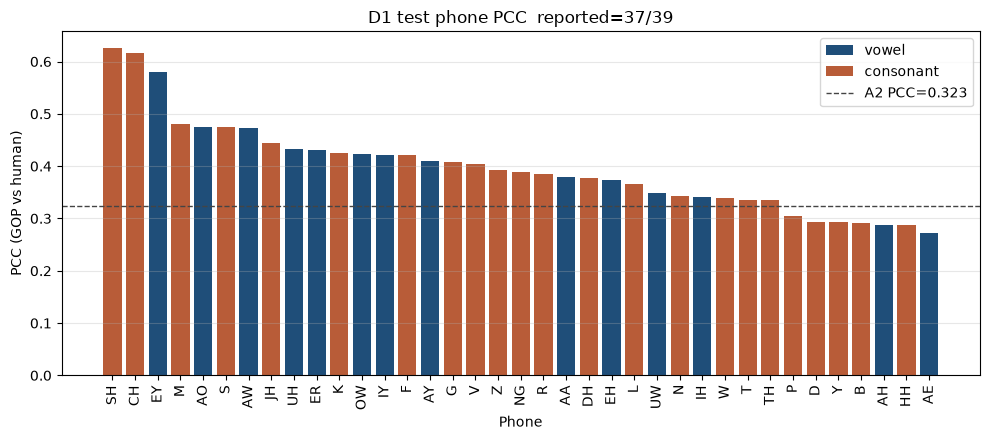

In [2]:
plot_phones = phones[(phones["aggregate"] == False) & (phones["reported"] == True)].copy()
plot_phones = plot_phones.sort_values("pcc", ascending=False)
vowels = {
    "AA", "AE", "AH", "AO", "AW", "AY", "EH", "ER", "EY",
    "IH", "IY", "OW", "OY", "UH", "UW",
}
from matplotlib.patches import Patch
colors = ["#1f4e79" if p in vowels else "#b85c38" for p in plot_phones["phone"]]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(plot_phones["phone"], plot_phones["pcc"], color=colors, width=0.8)
ax.axhline(protocol["sanity_pcc"], color="#444444", linestyle="--", linewidth=1, label=f"A2 PCC={protocol['sanity_pcc']:.3f}")
ax.set_ylabel("PCC (GOP vs human)")
ax.set_xlabel("Phone")
ax.set_title(f"D1 test phone PCC  reported={int(plot_phones.shape[0])}/{d1['n_phones']}")
ax.tick_params(axis="x", labelrotation=90)
handles = [
    Patch(facecolor="#1f4e79", label="vowel"),
    Patch(facecolor="#b85c38", label="consonant"),
]
ax.legend(handles=handles + ax.get_legend_handles_labels()[0], loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "d1_phone_pcc.png", dpi=140)
plt.show()

## D2 — Per-speaker PCC distribution

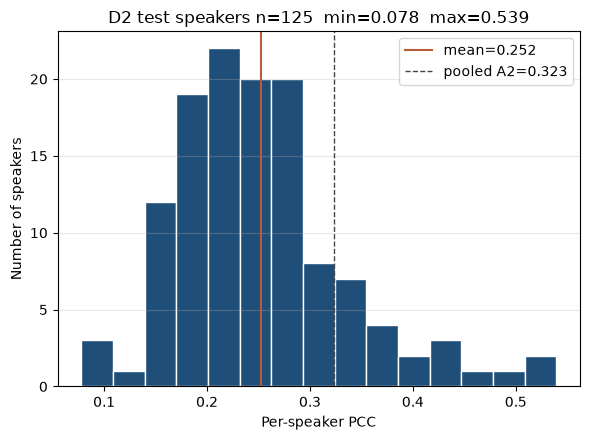

In [3]:
reported_spk = speakers[speakers["reported"] == True].copy()
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.hist(reported_spk["pcc"], bins=15, color="#1f4e79", edgecolor="white")
ax.axvline(d2["pcc_mean"], color="#b85c38", linewidth=1.5, label=f"mean={d2['pcc_mean']:.3f}")
ax.axvline(protocol["sanity_pcc"], color="#444444", linestyle="--", linewidth=1, label=f"pooled A2={protocol['sanity_pcc']:.3f}")
ax.set_xlabel("Per-speaker PCC")
ax.set_ylabel("Number of speakers")
ax.set_title(f"D2 test speakers n={int(len(reported_spk))}  min={d2['pcc_min']:.3f}  max={d2['pcc_max']:.3f}")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "d2_speaker_pcc_hist.png", dpi=140)
plt.show()

## D3 — Score strata (not proficiency)

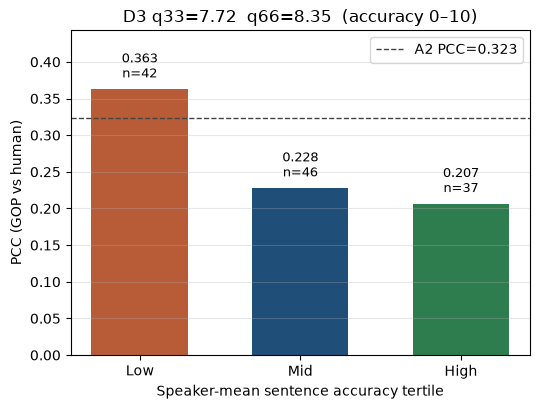

In [4]:
order = ["Low", "Mid", "High"]
plot_strata = strata.set_index("score_stratum").loc[order].reset_index()
fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.bar(plot_strata["score_stratum"], plot_strata["pcc"], color=["#b85c38", "#1f4e79", "#2e7d4f"], width=0.6)
ax.axhline(protocol["sanity_pcc"], color="#444444", linestyle="--", linewidth=1, label=f"A2 PCC={protocol['sanity_pcc']:.3f}")
for x, pcc, n_spk in zip(plot_strata["score_stratum"], plot_strata["pcc"], plot_strata["n_speakers"]):
    ax.text(x, pcc + 0.01, f"{pcc:.3f}\nn={int(n_spk)}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("PCC (GOP vs human)")
ax.set_xlabel("Speaker-mean sentence accuracy tertile")
ax.set_title(f"D3 q33={d3['q33']:.2f}  q66={d3['q66']:.2f}  (accuracy 0–10)")
ax.set_ylim(0, max(plot_strata["pcc"].max() + 0.08, protocol["sanity_pcc"] + 0.05))
ax.legend(loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "d3_stratum_pcc.png", dpi=140)
plt.show()